In [1]:
pip install fairlearn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Fairness in AI

from fairlearn.metrics import MetricFrame, selection_rate

# True outcomes and predictions
y_true = [1, 0, 1, 0, 1]
y_pred = [1, 0, 0, 0, 1]
sensitive_features = ["Male", "Female", "Male", "Female", "Male"]

metric_frame = MetricFrame(metrics = selection_rate,
                          y_true = y_true,
                          y_pred = y_pred,
                          sensitive_features = sensitive_features)

print(metric_frame.by_group)

sensitive_feature_0
Female    0.000000
Male      0.666667
Name: selection_rate, dtype: float64


In [3]:
pip install shap xgboost

Note: you may need to restart the kernel to use updated packages.


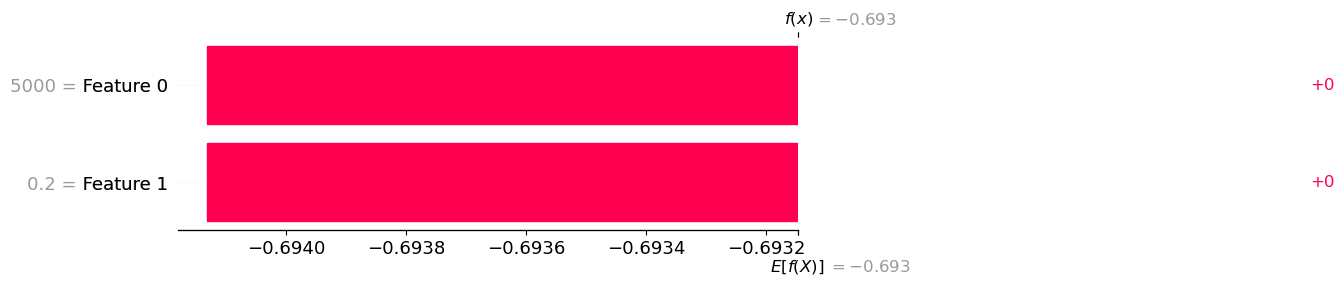

In [4]:
# Transparency in AI

import shap
import xgboost as xgb

# Sample data
X = [[5000, 0.2], [7000, 0.5], [3000, 0.1]]       # income. debt_ratio
y = [1, 0, 0]

model = xgb.XGBClassifier()                       # XGBoost --> train a classificatoin model
model.fit(X, y)

explainer = shap.Explainer(model)                 # SHAP --> to explain model prediction
shap_values = explainer(X)                        # Creates am explanation object for the trained model.

shap.plots.waterfall(shap_values[0])               # Shows why model predicted 1st sample

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Sample dataset
X = pd.DataFrame({
    "income" : [50, 30, 70, 25, 60, 40, 80, 35, 55, 65, 45, 75],
    "debt_ratio" : [0.2, 0.1, 0.5, 0.3, 0.4, 0.2, 0.6, 0.3, 0.25, 0.35, 0.15, 0.55]
})
y = [1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1]

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)
model = LogisticRegression(solver = "liblinear")                  # The solver is the algorithm that performs this optimization.
model.fit(X_train, y_train)

# Predict & Evaluate
y_pred = model.predict(X_test)
print("Accuarcy: ", accuracy_score(y_test, y_pred))

# Optional: Cross-Validation
scores = cross_val_score(model, X, y, cv=4)
print("CV Scores: ", scores)

Accuarcy:  0.6666666666666666
CV Scores:  [0.66666667 0.66666667 0.66666667 0.66666667]


In [6]:
!python --version

Python 3.13.9


**04-03-2026**
# **End-To-End ML/AI Project**
### Define the Problem (Most Important Step)
* Before touching code, ask:
  * What iproblem are we solving?
  * Classification or Regression
  * What is success?
  * What metric matters?

### Data Collection
* Machine Learning depends on data.
* Sources:
  * CSV files
  * Databases
  * Kaggle Dataset

### Data Cleaning & Preprocessing
* Raw data is messy.
* Tasks include:
  * Remove null values
  * Remove duplicates
  * Handle missing values
  * Convert text to lowercase
  * Remove stopwords
  * Encode categorical variables
  * Normalize numerical data

### Feature Engineering
* Converts raw data into useful features.
* Examples:
  * Text
  * TF-IDF
  * Word Embeddings

### Model Selection
* Choose the right algorithm.
  * Logistic Regression
  * Decision Tree
  * Random Forest
  * SVM / SVC
  * Neural Networks
  * Linear Regression

### Model Training
* Split data
* Train model on training data.
* Model learns patterns from data.

### Model Evaluation
* Test model performace on unseen data.
  * Classification metrics
  * Regression metrics

# **Deployment**
### Real Example: Spam Detection Project
**Step 1:**
Define problem -> Classify email as spam<br>
**Step 2:**
Download spam dataset<br>
**Step 3:**
Clean text<br>
**Step 4:**
Convert text to TF-IDF vectors<br>
**Step 5:**
Train Logistic Regression<br>
**Step 6:**
Evaluate using accuracy & F1-Score<br>

### Project Workflow
||
|:--:|
|Raw Text|
|Text Cleaning|
|TF-IDF Vectorization|
|Train-Test Split|
|Logistic Regression|
|Evaluation (Accuracy, F1)|
|Custom Prediction|

# **Project Development**
## build complete ML pipeline on real dataset

In [7]:
# =============================================
# Step 1: Define Problem
# Binary Classification
# Classify email/SMS as spam (1) or Not Spam (0)
# =============================================

import pandas as pd
import numpy as np
import re
import string


# =============================================
# step 2: Load Dataset
# Download SMS Spam Collection Dataset
# Save as: spam.csv
# =============================================

df = pd.read_csv("spam.csv", encoding="latin-1")

# Keep Only necessary columns
df = df[["v1", "v2"]]
df.columns = ["label", "message"]

print("Dataset Shape: ", df.shape)
print(df.head())

# Convert labels to numeric
df["label"] = df["label"].map({"ham": 0, "spam": 1})


# =============================================
# Step 3: Clean Text
# =============================================

def clean_text(text):
  text = text.lower()        # Lowercase
  text = re.sub(r"http\S+", "", text)     # remove URLs
  text = re.sub(r"\d+", "", text)         # remove numbers
  text = text.translate(str.maketrans("", "", string.punctuation))   # remove punctuation
  text = text.strip()
  return text

df["message"] = df["message"].apply(clean_text)

print("\nCleaned Sample: ")
print(df["message"].head())


# =============================================
# Step 4: Convert Text to TF-IDF
# =============================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

vectorizer = TfidfVectorizer(stop_words = "english")

X = vectorizer.fit_transform(df["message"])
y = df["label"]

print("\nFeature Matrix Shape: ", X.shape)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)


# =============================================
# Step 5: Train Logistic Regression
# =============================================

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

print("\nModel Training Completed!")


# =============================================
# Step 6: Evaluate Model
# =============================================

from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Evaluation")
print("Accuracy: ", round(accuracy, 4))
print("F1 Score: ", round(f1, 4))

print("\nDetailed Classification Report: ")
print(classification_report(y_test, y_pred))


# =============================================
# Test with Custom Input
# =============================================

def predict_message(message):
  message = clean_text(message)
  message_vector = vectorizer.transform([message])
  prediction = model.predict(message_vector)[0]
  return "Spam" if prediction == 1 else "Not Spam"

print("\nCustom Prediction Example: ")
print(predict_message("Congratulations! You won a free lottery ticket"))

Dataset Shape:  (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Cleaned Sample: 
0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in  a wkly comp to win fa cup final...
3          u dun say so early hor u c already then say
4    nah i dont think he goes to usf he lives aroun...
Name: message, dtype: object

Feature Matrix Shape:  (5572, 8281)

Model Training Completed!

Model Evaluation
Accuracy:  0.9444
F1 Score:  0.7459

Detailed Classification Report: 
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       965
           1       0.97      0.61    

**Applying Different Graphs for the Project**

Dataset Shape:  (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


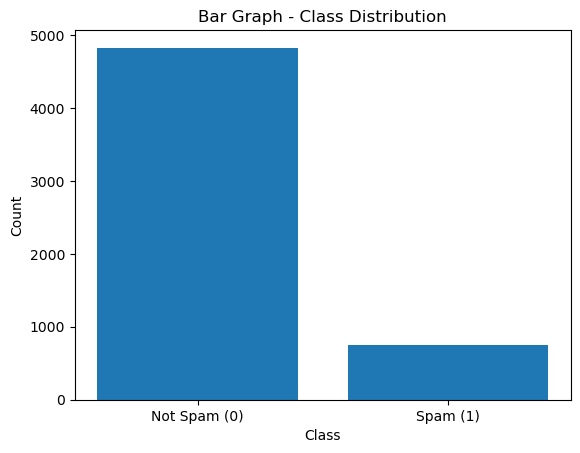

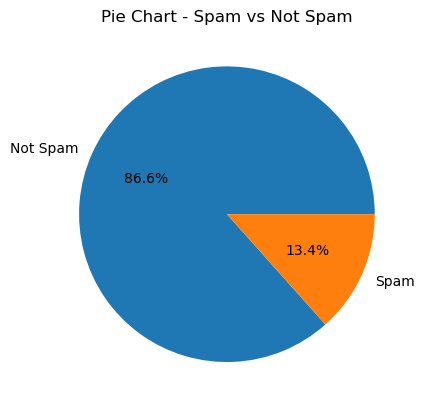

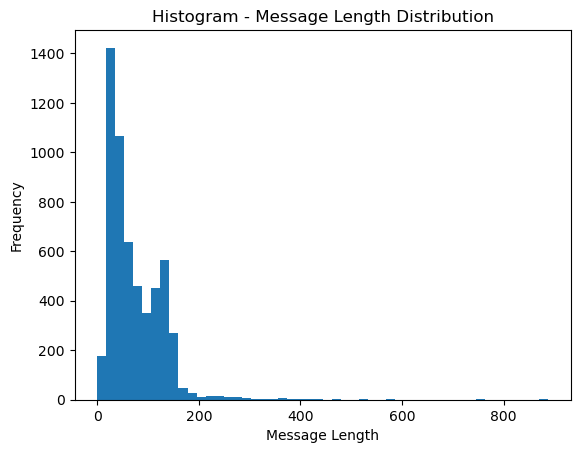



Feature Matrix Shape:  (5572, 8281)
Model Training Completed!

Model Evaluation
Accuracy:  0.9444
F1 Score:  0.7459

Classification Report: 

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       965
           1       0.97      0.61      0.75       150

    accuracy                           0.94      1115
   macro avg       0.96      0.80      0.86      1115
weighted avg       0.95      0.94      0.94      1115



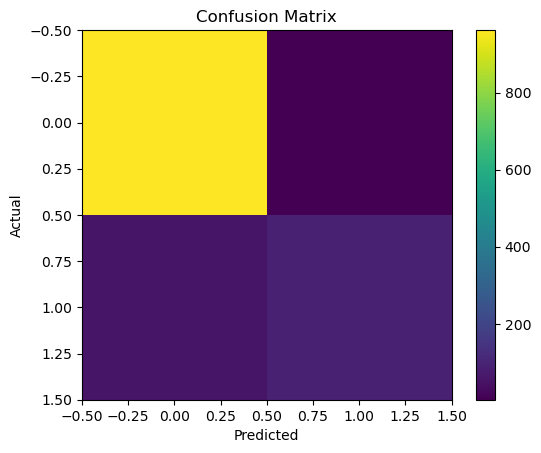

Confusion Matrix:
 [[962   3]
 [ 59  91]]


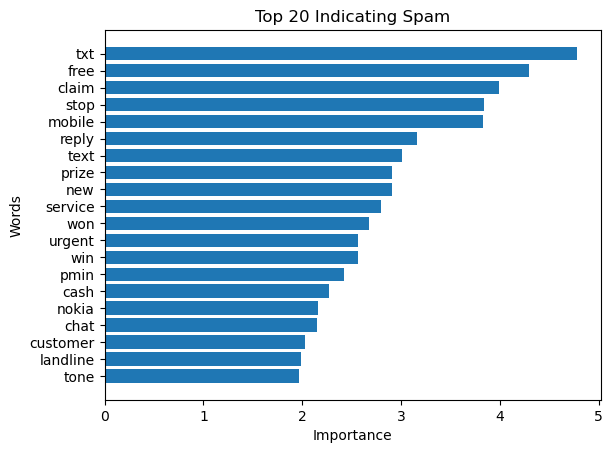

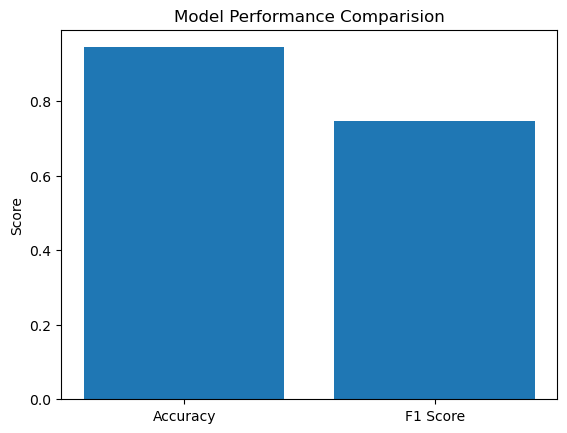


Custom Prediction Example: 
Spam


In [8]:
# =============================================
# Step 1: Import Libraries
# =============================================

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


# =============================================
# Step 2: Load Dataset
# =============================================

df = pd.read_csv("spam.csv", encoding = "latin-1")
df = df[["v1", "v2"]]
df.columns = ["label", "message"]

print("Dataset Shape: ", df.shape)
print(df.head())

# Convert labels to numeric
df["label"] = df["label"].map({"ham": 0, "spam": 1})


# =============================================
# Step 3: Text Cleaning
# =============================================

def clean_text(text):
  text = text.lower()
  text = re.sub(r"http\S+", "", text)
  text = re.sub(r"\d+", "", text)
  text = text.translate(str.maketrans("", "", string.punctuation))
  text = text.strip()
  return text

df["message"] = df["message"].apply(clean_text)


# =============================================
# Grpah 1: BAR GRAPH - Class Distribution
# =============================================

label_counts = df["label"].value_counts()

plt.figure()
plt.bar(["Not Spam (0)", "Spam (1)"], label_counts.values)
plt.title("Bar Graph - Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()
print("\n")


# =============================================
# Graph 2: PIE CHART - Class Distribution
# =============================================

plt.figure()
plt.pie(label_counts.values, labels = ["Not Spam", "Spam"], autopct = "%1.1f%%")
plt.title("Pie Chart - Spam vs Not Spam")
plt.show()
print("\n")


# =============================================
# Graph 3: HISTOGRAM - Message Length Distribution
# =============================================

df["message_length"] = df["message"].apply(len)

plt.figure()
plt.hist(df["message_length"], bins = 50)
plt.title("Histogram - Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()
print("\n")


# =============================================
# Step 4: TF-IDF Vectorization
# =============================================

vectorizer = TfidfVectorizer(stop_words = "english")
X = vectorizer.fit_transform(df["message"])
y = df["label"]

print("Feature Matrix Shape: ", X.shape)


# =============================================
# Step 5: Train-Test-Split
# =============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)


# =============================================
# Step 6: Train Logistic Regression
# =============================================

model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

print("Model Training Completed!")


# =============================================
# Step 7: Model Evaluation
# =============================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Evaluation")
print("Accuracy: ", round(accuracy, 4))
print("F1 Score: ", round(f1, 4))
print("\nClassification Report: \n")
print(classification_report(y_test, y_pred))


# =============================================
# Graph 4: CONFUSION MATRIX
# =============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

print("Confusion Matrix:\n", cm)


# =============================================
# Graph 5: TOP @) IMPORTANT SPAM WORDS
# =============================================

feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = model.coef_[0]

top_indices = np.argsort(coefficients)[-20:]
top_words = feature_names[top_indices]
top_values = coefficients[top_indices]

plt.figure()
plt.barh(top_words, top_values)
plt.title("Top 20 Indicating Spam")
plt.xlabel("Importance")
plt.ylabel("Words")
plt.show()
print("\n")


# =============================================
# Graph 6: ACCURACY VS F! SCORE
# =============================================

plt.figure()
plt.bar(["Accuracy", "F1 Score"], [accuracy, f1])
plt.title("Model Performance Comparision")
plt.ylabel("Score")
plt.show()


# =============================================
# Step 8: Custom Prediction Function
# =============================================

def predict_message(message):
  message =clean_text(message)
  message_vector = vectorizer.transform([message])
  prediction = model.predict(message_vector)[0]
  return "Spam" if prediction == 1 else "Not Spam"

print("\nCustom Prediction Example: ")
print(predict_message("Congratulations! You won a free lottery ticket"))

**Task**<br>
In the existing project do some changes like
* first you have to print all the data from the file
* Second do the changes in bar graph - change the colour of the bar, and pie graph in vertical
* After feature matrix display the data

Dataset Shape:  (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Data: 
      label                                            message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
...    ...                                                ...
5567  spam  This is the 2nd time we have tried 2 contact u...
5568   ham              Will Ì_ b going to esplanade fr home?
5569   ham  Pity, * was in mood for that. So...any oth

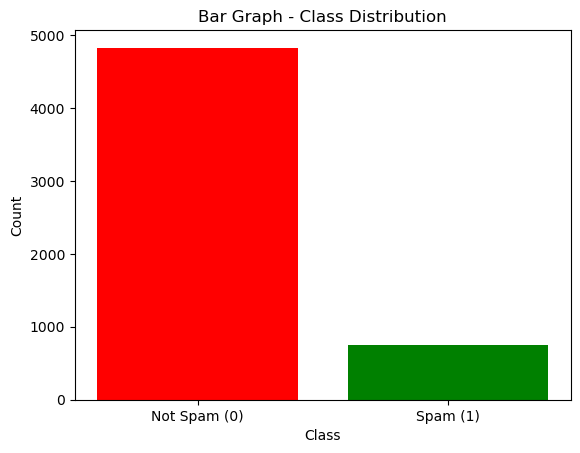

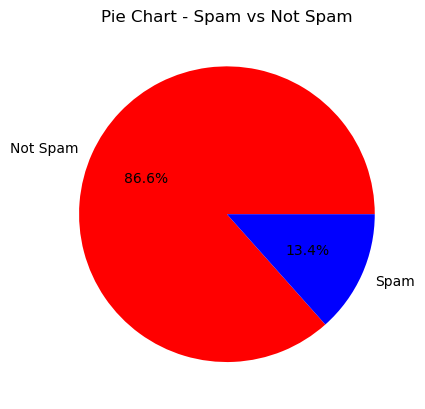

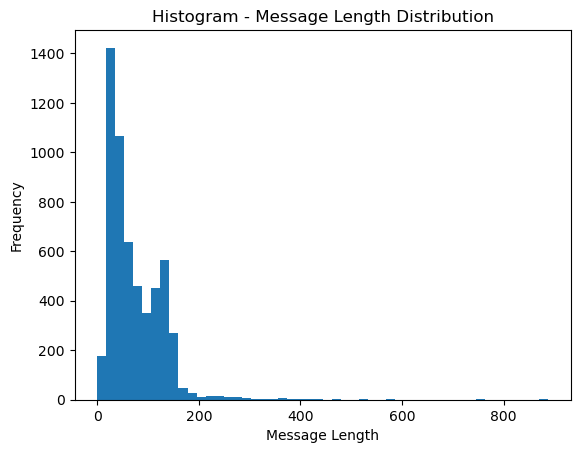



Feature Matrix Shape:  (5572, 8281)
Data: 
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 41054 stored elements and shape (5572, 8281)>
  Coords	Values
  (0, 3615)	0.3506894305607562
  (0, 5321)	0.2742934671141265
  (0, 1501)	0.2715848236082822
  (0, 458)	0.26667094878285835
  (0, 897)	0.2962638480692937
  (0, 2848)	0.19518886016165243
  (0, 8011)	0.24183826557783117
  (0, 3767)	0.2875032860269879
  (0, 895)	0.33477096814205043
  (0, 1221)	0.2962638480692937
  (0, 2809)	0.16457560558825957
  (0, 229)	0.3506894305607562
  (0, 7780)	0.19995345815712037
  (1, 4884)	0.2741803362458879
  (1, 3803)	0.4080505634471753
  (1, 3583)	0.5233273701797004
  (1, 7905)	0.4313385731102942
  (1, 4915)	0.5462557824449175
  (2, 2548)	0.1245064784748692
  (2, 2150)	0.38776895615937373
  (2, 7962)	0.20524794736929183
  (2, 1336)	0.2118686684872658
  (2, 7919)	0.1599695015604769
  (2, 2278)	0.5060006898551237
  (2, 1557)	0.21727819152397634
  :	:
  (5567, 4377)	0.33255981936948137
  (5567, 

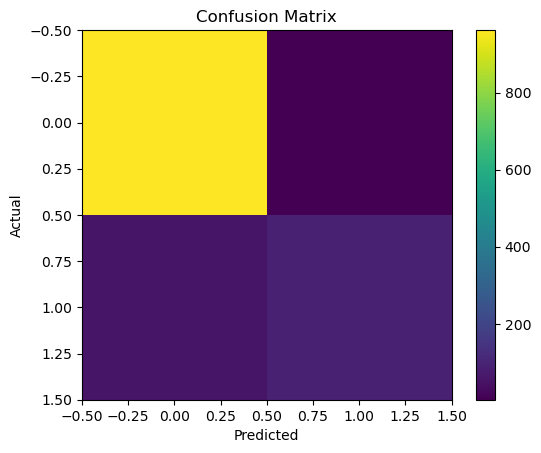

Confusion Matrix:
 [[962   3]
 [ 59  91]]


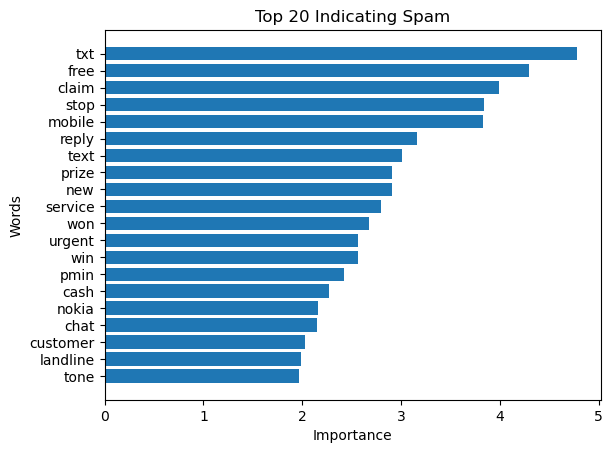

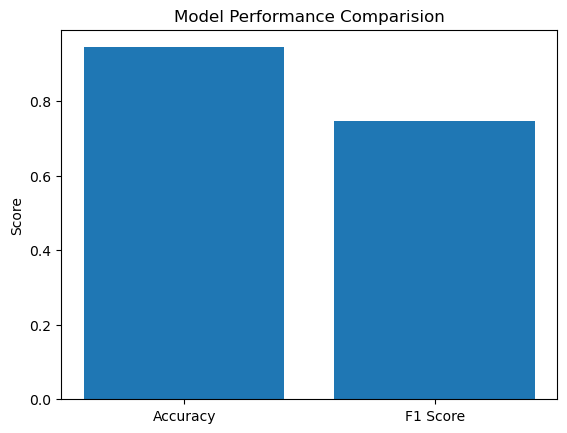


Custom Prediction Example: 
Spam


In [9]:
# =============================================
# Step 1: Import Libraries
# =============================================

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


# =============================================
# Step 2: Load Dataset
# =============================================

df = pd.read_csv("spam.csv", encoding = "latin-1")
df = df[["v1", "v2"]]
df.columns = ["label", "message"]

print("Dataset Shape: ", df.shape)
print(df.head())
print("Data: \n",df)

# Convert labels to numeric
df["label"] = df["label"].map({"ham": 0, "spam": 1})


# =============================================
# Step 3: Text Cleaning
# =============================================

def clean_text(text):
  text = text.lower()
  text = re.sub(r"http\S+", "", text)
  text = re.sub(r"\d+", "", text)
  text = text.translate(str.maketrans("", "", string.punctuation))
  text = text.strip()
  return text

df["message"] = df["message"].apply(clean_text)


# =============================================
# Grpah 1: BAR GRAPH - Class Distribution
# =============================================

label_counts = df["label"].value_counts()

plt.figure()
plt.bar(["Not Spam (0)", "Spam (1)"], label_counts.values, color = ["red","green"])
plt.title("Bar Graph - Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()
print("\n")


# =============================================
# Graph 2: PIE CHART - Class Distribution
# =============================================

plt.figure()
plt.pie(label_counts.values, labels = ["Not Spam", "Spam"], autopct = "%1.1f%%", colors=["red","blue"])
plt.title("Pie Chart - Spam vs Not Spam")
plt.show()
print("\n")


# =============================================
# Graph 3: HISTOGRAM - Message Length Distribution
# =============================================

df["message_length"] = df["message"].apply(len)

plt.figure()
plt.hist(df["message_length"], bins = 50)
plt.title("Histogram - Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()
print("\n")


# =============================================
# Step 4: TF-IDF Vectorization
# =============================================

vectorizer = TfidfVectorizer(stop_words = "english")
X = vectorizer.fit_transform(df["message"])
y = df["label"]

print("Feature Matrix Shape: ", X.shape)
print("Data: \n", X)

# =============================================
# Step 5: Train-Test-Split
# =============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)


# =============================================
# Step 6: Train Logistic Regression
# =============================================

model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

print("Model Training Completed!")


# =============================================
# Step 7: Model Evaluation
# =============================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Evaluation")
print("Accuracy: ", round(accuracy, 4))
print("F1 Score: ", round(f1, 4))
print("\nClassification Report: \n")
print(classification_report(y_test, y_pred))


# =============================================
# Graph 4: CONFUSION MATRIX
# =============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

print("Confusion Matrix:\n", cm)


# =============================================
# Graph 5: TOP 20 IMPORTANT SPAM WORDS
# =============================================

feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = model.coef_[0]

top_indices = np.argsort(coefficients)[-20:]
top_words = feature_names[top_indices]
top_values = coefficients[top_indices]

plt.figure()
plt.barh(top_words, top_values)
plt.title("Top 20 Indicating Spam")
plt.xlabel("Importance")
plt.ylabel("Words")
plt.show()
print("\n")


# =============================================
# Graph 6: ACCURACY VS F! SCORE
# =============================================

plt.figure()
plt.bar(["Accuracy", "F1 Score"], [accuracy, f1])
plt.title("Model Performance Comparision")
plt.ylabel("Score")
plt.show()


# =============================================
# Step 8: Custom Prediction Function
# =============================================

def predict_message(message):
  message =clean_text(message)
  message_vector = vectorizer.transform([message])
  prediction = model.predict(message_vector)[0]
  return "Spam" if prediction == 1 else "Not Spam"

print("\nCustom Prediction Example: ")
print(predict_message("Congratulations! You won a free lottery ticket"))